[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/experiments/sjepa/gavd5-drift/neurips-brain-body/02_extract_and_watch_skeletons.ipynb)

# 02. Extract and watch BlazePose skeletons

Use each annotation's frame span and bbox to extract the intended walker without compressing the gait timeline.

**Research use only.** This tutorial does not diagnose a person or validate a clinical device.

**Run it:** locally, from `experiments/sjepa/gavd5-drift`, run `uv sync` and then `uv run jupyter lab neurips-brain-body`. In Colab, use the badge and run the setup cell. Restart the kernel after changing `experiments/sjepa/gavd5-drift/.env`.

**Keep the walk visible:** notebook 01 opens the source video, and notebook 02 shows frame, bbox, and skeleton alignment. Revisit those views whenever a latent or classifier result looks surprising.


In [1]:
from pathlib import Path
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/brilliantbeaver/alexpose.git"

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy", "pandas", "scipy", "scikit-learn", "matplotlib",
        "seaborn", "torch", "tqdm", "python-dotenv", "yt-dlp[default]",
        "opencv-python-headless", "mediapipe<1", "joblib", "pyarrow",
    ])
    clone_dir = Path("/content/alexpose")
    if not (clone_dir / ".git").exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)])
    os.chdir(clone_dir)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
        print(f"Ignoring invalid ALEXPOSE_ROOT: {candidate}")
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd5-drift"
NOTEBOOK_DIR = EXPERIMENT_DIR / "neurips-brain-body"

try:
    from dotenv import load_dotenv
    load_dotenv(EXPERIMENT_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be smoke or real")
if MODE == "smoke":
    print(
        "SMOKE MODE: hand-authored motions test code paths only. "
        "They have no pathophysiological or clinical validity."
    )

PREFERRED_ROOT = Path(
    os.getenv(
        "GAVD4_ROOT",
        "/Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4",
    )
).expanduser()

requested_data = os.getenv("GAVD4_DATA_DIR") or os.getenv("GAVD_DATA_GAVD_DIR")
if requested_data and Path(requested_data).expanduser().exists():
    DATA_GAVD_DIR = Path(requested_data).expanduser()
elif requested_data:
    print(f"Ignoring missing GAVD CSV path: {Path(requested_data).expanduser()}")
    if (EXPERIMENT_DIR / "data-gavd").exists():
        DATA_GAVD_DIR = EXPERIMENT_DIR / "data-gavd"
    elif (PREFERRED_ROOT / "data-gavd").exists():
        DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
    else:
        DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"
elif (EXPERIMENT_DIR / "data-gavd").exists():
    DATA_GAVD_DIR = EXPERIMENT_DIR / "data-gavd"
elif (PREFERRED_ROOT / "data-gavd").exists():
    DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
else:
    DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"

requested_youtube = os.getenv("GAVD4_YOUTUBE_DIR") or os.getenv("GAVD_YOUTUBE_DIR")
if requested_youtube:
    YOUTUBE_DIR = Path(requested_youtube).expanduser()
elif PREFERRED_ROOT.exists():
    YOUTUBE_DIR = PREFERRED_ROOT / "youtube"
else:
    YOUTUBE_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd5-drift" / "work" / "youtube"

CACHE_DIR = Path(
    os.getenv("GAVD_CACHE_DIR", EXPERIMENT_DIR / "work" / "cache")
).expanduser()
ARTIFACT_ROOT = Path(
    os.getenv("GAVD_ARTIFACT_DIR", EXPERIMENT_DIR / "work" / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import SVG, display


def show_tutorial_svg(filename):
    '''Render a repository SVG reliably in local Jupyter and Colab.'''
    path = EXPERIMENT_DIR / "images" / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing tutorial figure {path}. Clone the full alexpose repository."
        )
    display(SVG(filename=str(path)))

print(f"mode: {MODE}")
print(f"project: {PROJECT_ROOT}")
print(f"workshop notebooks: {NOTEBOOK_DIR}")
print(f"GAVD CSVs: {DATA_GAVD_DIR}")
print(f"YouTube cache: {YOUTUBE_DIR}")
print(f"artifacts: {ARTIFACT_DIR}")


mode: real
project: C:\Users\alexm\dev\alexpose
workshop notebooks: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\neurips-brain-body
GAVD CSVs: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\data-gavd
YouTube cache: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\youtube
artifacts: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\artifacts\real


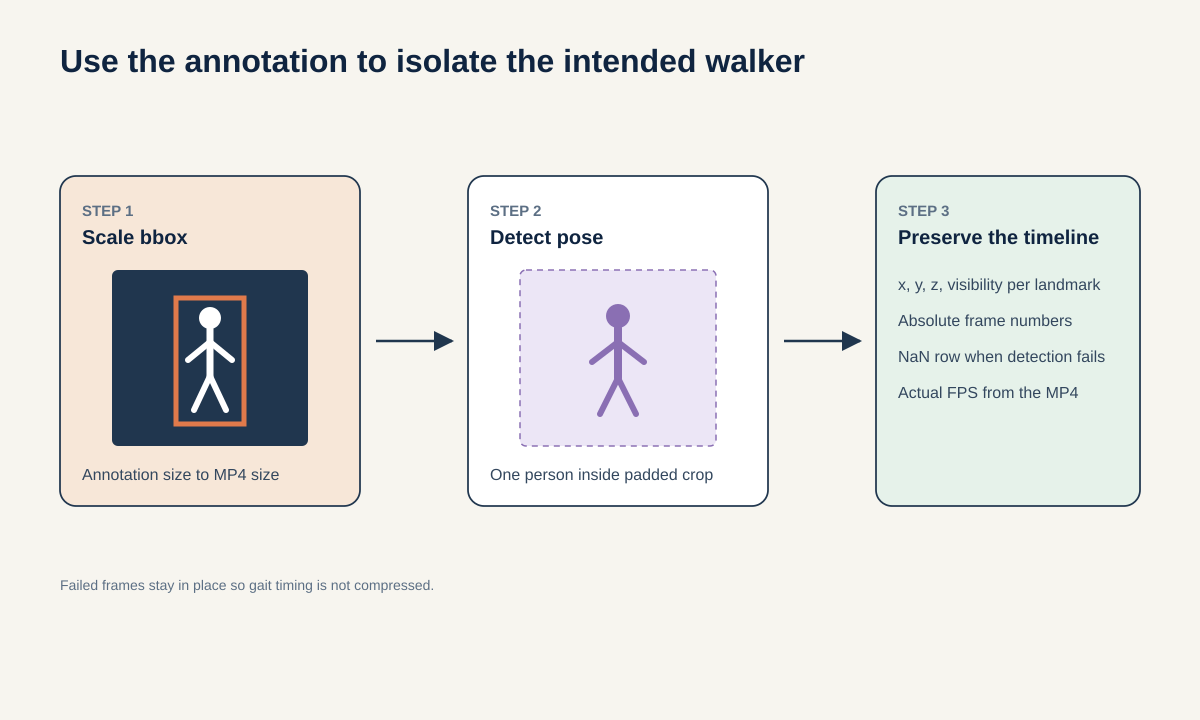

In [2]:
show_tutorial_svg("05_pose_extraction.svg")


## The evaluation boundary: a YouTube source, not a clip

One YouTube upload can contribute several annotated gait sequences. Those clips share the same person, camera, compression, background, and pose-estimation failure modes. A sequence-level random split can therefore put near-duplicates on both sides and make memorization look like generalization. The independent unit available in GAVD is the source `video_id`: every sequence from one source must inherit the same role.

**Inductive evaluation** keeps a source video completely unseen by the encoder, predictor, readout, and model-selection logic until testing. **Transductive evaluation** lets the representation learn from the eventual test inputs, even without their labels. Transductive analysis can describe a fixed corpus, but it cannot estimate performance on a new source.

The frozen protocol uses five outer source-grouped folds. Within each outer fold, development sources are separated again into train and validation roles. Train sources receive gradient updates; validation sources choose hyperparameters and stopping; test sources are opened once after the checkpoint is frozen. Each source is outer-test exactly once. Folder labels help balance folds but never permit a source to cross roles.

Availability and quality are separate gates. The split registry is frozen from a dated metadata-public snapshot. Later decoded-frame or pose-QC failures are recorded against that registry rather than causing a convenient re-split. This protects the test boundary while keeping attrition auditable.


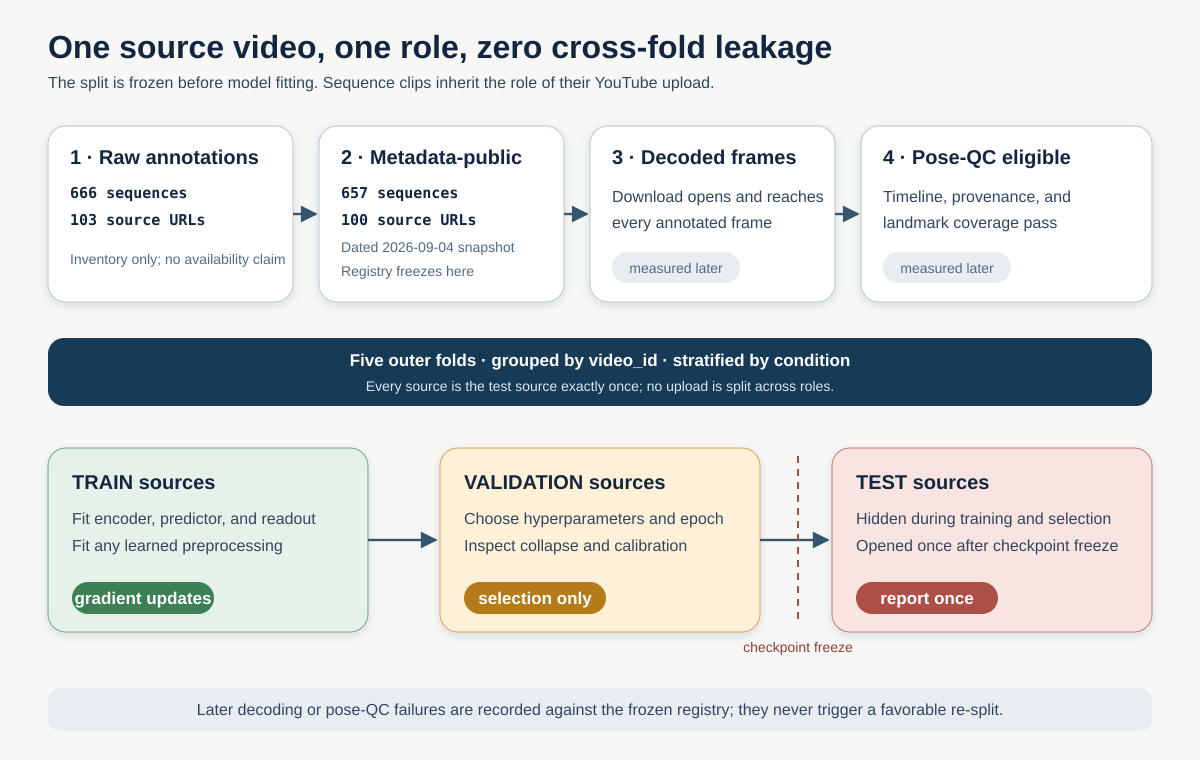

In [3]:
show_tutorial_svg("22_inductive_source_split.svg")


In [4]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
MASK_KEYPOINT_NAMES = [
    "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE",
    "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
assert MASK_KEYPOINTS == sorted(set(MASK_KEYPOINTS))
assert [BLAZEPOSE_33[i] for i in MASK_KEYPOINTS] == MASK_KEYPOINT_NAMES


## How to read the progress display

Notebook 02 uses the same live `NotebookTaskProgress` contract as notebook 00,
but the plan becomes more detailed after the frozen manifest is known. The
display first validates the protocol, then expands to one auditable unit per
selected sequence plus one whole-cohort cache-audit unit. A sequence is counted
only after its cache was validated, migrated, newly extracted, deliberately not
run, or recorded as a residual failure.

The counters distinguish **reused**, **newly computed**, **skipped**, **failed**,
and **retry** events. Retries do not advance the bar because they are another
attempt at the same scientific unit. The ETA uses successful non-cache units and
is therefore a rough operational estimate, not evidence about model quality.
Cache readiness and pose-QC counts—not a green bar alone—determine whether
notebook 04 may train.


In [5]:
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
from notebook_progress import NotebookTaskProgress

pose_progress = NotebookTaskProgress(
    'Pose extraction and cache-audit progress',
    "stage",
    refresh_seconds=0.5,
)
pose_progress.start(
    1,
    profile=MODE,
    note="The plan expands after the selected manifest is known.",
)

with pose_progress.unit(1, "Validate the frozen protocol and fold roles"):
    import ast
    import json

    if str(NOTEBOOK_DIR) not in sys.path:
        sys.path.insert(0, str(NOTEBOOK_DIR))

    from evaluation_protocol import (
        CONDITIONS as PROTOCOL_CONDITIONS,
        expand_split,
        manifest_fingerprint,
        split_fingerprint,
        validate_split_registry,
    )

    CONDITIONS = list(PROTOCOL_CONDITIONS)
    PROTOCOL_DIR = ARTIFACT_DIR / "evaluation_protocol"
    MANIFEST_PATH = PROTOCOL_DIR / "eligible_sequence_manifest.csv"
    REGISTRY_PATH = PROTOCOL_DIR / "source_split_registry.csv"
    CONTRACT_PATH = PROTOCOL_DIR / "source_split_contract.json"

    for required_path in (MANIFEST_PATH, REGISTRY_PATH, CONTRACT_PATH):
        if not required_path.is_file():
            raise FileNotFoundError(
                f"Missing frozen protocol artifact {required_path}. Run notebook 01 first."
            )

    protocol_manifest = pd.read_csv(MANIFEST_PATH)
    source_split_registry = pd.read_csv(REGISTRY_PATH)
    split_contract = json.loads(CONTRACT_PATH.read_text(encoding="utf-8"))
    validate_split_registry(source_split_registry, protocol_manifest)

    MANIFEST_SHA256 = manifest_fingerprint(protocol_manifest)
    SPLIT_SHA256 = split_fingerprint(source_split_registry)
    if MANIFEST_SHA256 != split_contract["manifest_sha256"]:
        raise ValueError("Manifest hash does not match notebook 01's split contract")
    if SPLIT_SHA256 != split_contract["split_sha256"]:
        raise ValueError("Split hash does not match notebook 01's split contract")

    if "decoded_frame_eligible" not in protocol_manifest:
        raise ValueError("Notebook 01 has not attached decoded-frame eligibility")
    decoded_flag = (
        protocol_manifest["decoded_frame_eligible"]
        .astype(str).str.strip().str.lower().isin({"true", "1", "yes"})
    )
    decoded_manifest = protocol_manifest.loc[decoded_flag].copy()
    manifest_gate_label = "decoded-frame eligible"
    if decoded_manifest.empty:
        if MODE == "smoke":
            # A smoke run tests registry expansion and provenance plumbing only.
            # It never claims decoded eligibility and EXTRACT_POSES remains false.
            decoded_manifest = protocol_manifest.copy()
            decoded_manifest["eligibility_stage"] = (
                "smoke_registry_code_path_fixture_not_decoded"
            )
            manifest_gate_label = "SMOKE registry fixture (not decoded)"
            print(
                "SMOKE FIXTURE: no decoded sources; using metadata-public rows "
                "only to test split/provenance code. No pose extraction will run."
            )
        else:
            raise RuntimeError(
                "No decoded-frame-eligible sources. Complete notebook 01's "
                "download audit before real extraction."
            )

    # Extraction itself is deterministic and may cache every role. OUTER_FOLD says
    # which role label is displayed and embedded in the cache provenance; the full
    # registry hash and per-fold role map preserve all five assignments.
    OUTER_FOLD = int(os.getenv("SJEPA_OUTER_FOLD", "0"))
    if OUTER_FOLD not in set(source_split_registry["outer_fold"].astype(int)):
        raise ValueError(f"Unknown SJEPA_OUTER_FOLD={OUTER_FOLD}")
    manifest = expand_split(decoded_manifest, source_split_registry, OUTER_FOLD)
    SPLIT_VERSION = str(source_split_registry["split_version"].iloc[0])
    SPLIT_SEED = int(source_split_registry["split_seed"].iloc[0])


    def safe_literal(value):
        if value is None or pd.isna(value):
            return {}
        try:
            parsed = ast.literal_eval(str(value))
            return parsed if isinstance(parsed, dict) else {}
        except (ValueError, SyntaxError):
            return {}


    def split_roles_json_for_video(video_id):
        rows = source_split_registry.loc[
            source_split_registry["video_id"].eq(video_id),
            ["outer_fold", "role"],
        ].sort_values("outer_fold")
        return json.dumps(
            {str(int(row.outer_fold)): row.role for row in rows.itertuples(index=False)},
            sort_keys=True,
        )


    print(
        f"frozen protocol: {len(protocol_manifest)} metadata-public sequences / "
        f"{protocol_manifest['video_id'].nunique()} sources"
    )
    print(
        f"{manifest_gate_label}: {len(manifest)} sequences / "
        f"{manifest['video_id'].nunique()} sources"
    )
    print(f"outer fold shown: {OUTER_FOLD}; split SHA-256: {SPLIT_SHA256}")
    display(
        manifest.groupby(["role", "condition"])
        .agg(sequences=("sequence_id", "nunique"), sources=("video_id", "nunique"))
    )


frozen protocol: 657 metadata-public sequences / 100 sources
decoded-frame eligible: 655 sequences / 98 sources
outer fold shown: 0; split SHA-256: ff3518b87b1d1fa7d95efb1aea1711773137a21699967cb8015edb8d845ccbe1


sequences  sources
role       condition                        
test       cerebralpalsy         14        2
           myopathic             37        6
           normal                56        7
           parkinsons             9        2
           stroke                15        3
train      cerebralpalsy         38        6
           myopathic            111       17
           normal               169       19
           parkinsons            29        7
           stroke                45       11
validation cerebralpalsy          8        2
           myopathic             35        5
           normal                65        5
           parkinsons             9        2
           stroke                15        4

In [6]:
def synthetic_gait_sequence(condition="normal", frames=64, seed=0):
    '''Create a code-path fixture, not a physiological disease simulation.'''
    rng = np.random.default_rng(seed)
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    seq = np.zeros((frames, 33, 4), dtype=np.float32)
    seq[..., 3] = 1.0
    base = {
        11: (0.42, 0.28), 12: (0.58, 0.28),
        23: (0.45, 0.52), 24: (0.55, 0.52),
        25: (0.44, 0.70), 26: (0.56, 0.70),
        27: (0.43, 0.89), 28: (0.57, 0.89),
        29: (0.42, 0.92), 30: (0.58, 0.92),
        31: (0.39, 0.94), 32: (0.61, 0.94),
    }
    for joint, (x, y) in base.items():
        seq[:, joint, 0] = x
        seq[:, joint, 1] = y
    amplitude = 0.045
    lift = 0.025
    if condition == "parkinsons":
        amplitude *= 0.45
        lift *= 0.45
    if condition == "myopathic":
        seq[:, [11, 12], 0] += 0.03 * np.sin(phase)[:, None]
        seq[:, [23, 24], 0] += 0.018 * np.sin(phase)[:, None]
    for joint, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and joint == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            seq[:, knee, 1] -= 0.045
            seq[:, joint, 1] -= 0.02
        seq[:, joint, 0] += amplitude * wave
        seq[:, knee, 0] += 0.4 * amplitude * wave
        seq[:, foot, 0] += amplitude * wave
        seq[:, joint, 1] -= lift * np.maximum(wave, 0.0)
        seq[:, foot, 1] -= 0.7 * lift * np.maximum(wave, 0.0)
    seq[..., :3] += rng.normal(0.0, 0.0025, seq[..., :3].shape)
    return seq


def synthetic_corpus(conditions=None, n_per_condition=10, frames=64, seed=42):
    if conditions is None:
        conditions = [
            "normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"
        ]
    records = []
    counter = 0
    for condition in conditions:
        for sample in range(n_per_condition):
            records.append({
                "condition": condition,
                "sequence_id": f"smoke_{condition}_{sample:03d}",
                "video_id": f"smoke_video_{condition}_{sample // 2:02d}",
                "sequence": synthetic_gait_sequence(
                    condition=condition,
                    frames=frames,
                    seed=seed + counter,
                ),
            })
            counter += 1
    return records


## Extract clips without crossing the evaluation boundary

A source can contain several annotated walks, so extraction remains
sequence-specific while role assignment remains source-specific. All clips from
a `video_id` inherit the same train, validation, or test role in a given outer
fold.

Pose extraction uses a fixed MediaPipe model and fixed crop logic; it does not
fit to GAVD and can therefore be cached for all roles. Nevertheless, every NPZ
records the manifest hash, split hash, current fold/role, and the source's
complete five-fold role map. Later training code must still load only train rows,
use validation only for selection, and leave test rows untouched until the
checkpoint is frozen.

The eligibility ladder is monotone and auditable: metadata-public does not imply
decoded-frame eligible, and decoded-frame eligible does not imply pose-QC
eligible. A failed pose row remains on the original timeline with zero
visibility; quality rules remove or flag rows without redrawing folds.

### Recovery without hiding errors

Legacy v2 pose arrays are not recomputed merely because v3 added split
provenance. They may be upgraded only after exact identity, annotation-frame,
shape, FPS, and pose-model-hash checks. The new archive is verified before an
atomic replacement. A mismatch is an integrity error and cannot be migrated.

Extraction retries are narrower: a decoder or MediaPipe runtime failure gets a
small bounded retry with fresh state and exponential backoff. A stale schema,
missing video, too-short video, annotation mismatch, or unexpected programming
error is not retried because another identical attempt cannot repair it. Every
attempt and recovery recommendation is written to
`pose_extraction_report.csv`.

Pixel crop bounds are meaningful only at the resolution where they were
created. Newly extracted caches therefore store each decoded frame size and a
normalized copy of every crop. Legacy caches may lack those fields, so the
alignment preview always reprojects the original GAVD annotation into the
resolution of the frame it actually displays; it never overlays unscaled legacy
pixels on a different YouTube rendition.


In [7]:
import urllib.request
import hashlib
from functools import lru_cache
import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

from pose_cache import (
    CURRENT_EXTRACTION_VERSION,
    PermanentPoseExtractionError,
    TransientPoseExtractionError,
    atomic_savez_compressed,
)

from pose_geometry import (
    PoseGeometryError,
    normalize_pixel_bounds,
    scaled_crop_bounds,
)

POSE_MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/pose_landmarker/"
    "pose_landmarker_lite/float16/latest/pose_landmarker_lite.task"
)
POSE_MODEL_PATH = CACHE_DIR / "models" / "pose_landmarker_lite.task"


def ensure_pose_model():
    if POSE_MODEL_PATH.exists() and POSE_MODEL_PATH.stat().st_size > 1_000_000:
        return POSE_MODEL_PATH
    POSE_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    print(f"Downloading MediaPipe model to {POSE_MODEL_PATH}")
    urllib.request.urlretrieve(POSE_MODEL_URL, POSE_MODEL_PATH)
    return POSE_MODEL_PATH


@lru_cache(maxsize=1)
def pose_model_sha256():
    path = ensure_pose_model()
    return hashlib.sha256(path.read_bytes()).hexdigest()


def make_landmarker():
    model_path = ensure_pose_model()
    options = vision.PoseLandmarkerOptions(
        base_options=mp_python.BaseOptions(
            model_asset_path=str(model_path),
            delegate=mp_python.BaseOptions.Delegate.CPU,
        ),
        running_mode=vision.RunningMode.VIDEO,
        num_poses=1,
        min_pose_detection_confidence=0.45,
        min_pose_presence_confidence=0.45,
        min_tracking_confidence=0.45,
    )
    return vision.PoseLandmarker.create_from_options(options)


def find_video(condition, video_id):
    folder = Path(YOUTUBE_DIR) / condition
    video_suffixes = {".mp4", ".mkv", ".webm", ".mov", ".m4v"}
    exact = folder / f"{video_id}.mp4"
    if exact.exists() and exact.suffix.lower() in video_suffixes:
        return exact
    matches = sorted(
        path for path in folder.glob(f"{video_id}.*")
        if path.suffix.lower() in video_suffixes
        and not path.name.endswith(".part")
    )
    if matches:
        return matches[0]
    raise FileNotFoundError(
        f"No cached video for {condition}/{video_id}. Run notebook 01."
    )


def detect_pose_in_crop(
    frame_bgr, annotation_row, landmarker, timestamp_ms
):
    height, width = frame_bgr.shape[:2]
    try:
        x0, y0, x1, y1 = scaled_crop_bounds(
            annotation_row, frame_bgr.shape
        )
    except PoseGeometryError as error:
        frame_number = annotation_row.get("frame_num", "unknown")
        raise PermanentPoseExtractionError(
            f"Invalid annotation bbox at frame {frame_number}: {error}",
            failure_kind="invalid_annotation_bbox",
        ) from error
    crop = frame_bgr[y0:y1, x0:x1]
    rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    result = landmarker.detect_for_video(
        mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb),
        timestamp_ms,
    )
    sequence_row = np.full((33, 4), np.nan, dtype=np.float32)
    sequence_row[:, 3] = 0.0
    if not result.pose_landmarks:
        return sequence_row, (x0, y0, x1, y1)
    crop_height, crop_width = crop.shape[:2]
    for index, landmark in enumerate(result.pose_landmarks[0]):
        sequence_row[index, 0] = (x0 + landmark.x * crop_width) / width
        sequence_row[index, 1] = (y0 + landmark.y * crop_height) / height
        sequence_row[index, 2] = landmark.z * crop_width / width
        sequence_row[index, 3] = float(landmark.visibility or 0.0)
    return sequence_row, (x0, y0, x1, y1)


def extract_one_sequence(manifest_row):
    csv_path = Path(manifest_row["csv_path"])
    annotations = pd.read_csv(csv_path).sort_values("frame_num")
    annotations["frame_num"] = annotations["frame_num"].astype(int)
    by_frame = {
        int(row.frame_num): row
        for _, row in annotations.iterrows()
    }
    video_path = find_video(
        manifest_row["condition"], manifest_row["video_id"]
    )
    capture = cv2.VideoCapture(str(video_path))
    fps = float(capture.get(cv2.CAP_PROP_FPS))
    if not capture.isOpened() or fps <= 0:
        capture.release()
        raise TransientPoseExtractionError(
            f"Could not open or determine FPS for {video_path}",
            failure_kind="video_decode_open",
        )
    first_frame = int(annotations["frame_num"].min())
    last_frame = int(annotations["frame_num"].max())
    video_frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    if video_frame_count < last_frame:
        capture.release()
        raise PermanentPoseExtractionError(
            f"{video_path} has {video_frame_count} frames but annotations "
            f"reach frame {last_frame}",
            failure_kind="source_video_too_short",
        )
    capture.set(cv2.CAP_PROP_POS_FRAMES, first_frame - 1)
    pose_rows, frame_numbers, crop_bounds = [], [], []
    frame_sizes, crop_bounds_normalized = [], []
    try:
        with make_landmarker() as landmarker:
            for frame_number in range(first_frame, last_frame + 1):
                ok, frame = capture.read()
                if not ok:
                    break
                annotation = by_frame.get(frame_number)
                if annotation is None:
                    continue
                timestamp_ms = int(
                    round((frame_number - first_frame) * 1000.0 / fps)
                )
                pose_row, bounds = detect_pose_in_crop(
                    frame, annotation, landmarker, timestamp_ms
                )
                pose_rows.append(pose_row)
                frame_numbers.append(frame_number)
                crop_bounds.append(bounds)
                frame_size = (frame.shape[1], frame.shape[0])
                frame_sizes.append(frame_size)
                crop_bounds_normalized.append(
                    normalize_pixel_bounds(bounds, frame_size)
                )
    finally:
        # A retry must start with a new decoder and landmarker; never leak the
        # failed attempt's video handle into the next attempt.
        capture.release()
    if frame_numbers != annotations["frame_num"].tolist():
        raise TransientPoseExtractionError(
            f"Decoded {len(frame_numbers)} of {len(annotations)} annotated frames "
            f"for {manifest_row['sequence_id']}",
            failure_kind="video_decode_interrupted",
        )
    sequence = np.stack(pose_rows)
    output = (
        POSE_DIR
        / manifest_row["condition"]
        / f"{manifest_row['sequence_id']}.npz"
    )
    output.parent.mkdir(parents=True, exist_ok=True)
    atomic_savez_compressed(
        output,
        sequence=sequence,
        frame_numbers=np.asarray(frame_numbers, dtype=np.int32),
        crop_bounds=np.asarray(crop_bounds, dtype=np.int32),
        frame_sizes=np.asarray(frame_sizes, dtype=np.int32),
        crop_bounds_normalized=np.asarray(
            crop_bounds_normalized, dtype=np.float64
        ),
        crop_geometry_version=np.asarray("decoded_frame_normalized_v1"),
        crop_padding_fraction=np.asarray(0.15, dtype=np.float32),
        frame_number_origin=np.asarray(
            "one_based_annotation_to_zero_based_decoder"
        ),
        fps=np.asarray(fps, dtype=np.float32),
        sequence_id=np.asarray(manifest_row["sequence_id"]),
        video_id=np.asarray(manifest_row["video_id"]),
        condition=np.asarray(manifest_row["condition"]),
        source_csv=np.asarray(str(csv_path)),
        source_video=np.asarray(str(video_path)),
        extraction_version=np.asarray(CURRENT_EXTRACTION_VERSION),
        pose_model=np.asarray(POSE_MODEL_PATH.name),
        pose_model_sha256=np.asarray(pose_model_sha256()),
        visibility_threshold=np.asarray(0.45, dtype=np.float32),
        eligibility_stage=np.asarray("decoded_frame_eligible"),
        outer_fold=np.asarray(int(manifest_row["outer_fold"]), dtype=np.int16),
        split_role=np.asarray(str(manifest_row["role"])),
        split_version=np.asarray(SPLIT_VERSION),
        split_seed=np.asarray(SPLIT_SEED, dtype=np.int64),
        manifest_sha256=np.asarray(MANIFEST_SHA256),
        split_sha256=np.asarray(SPLIT_SHA256),
        split_roles_json=np.asarray(
            split_roles_json_for_video(manifest_row["video_id"])
        ),
    )
    coverage = float((sequence[..., 3] > 0.0).any(axis=1).mean())
    neuro_coverage = float(
        (sequence[:, MASK_KEYPOINTS, 3] >= 0.45).mean()
    )
    return {
        "condition": manifest_row["condition"],
        "sequence_id": manifest_row["sequence_id"],
        "video_id": manifest_row["video_id"],
        "outer_fold": int(manifest_row["outer_fold"]),
        "split_role": str(manifest_row["role"]),
        "manifest_sha256": MANIFEST_SHA256,
        "split_sha256": SPLIT_SHA256,
        "frames": len(sequence),
        "pose_frame_coverage": coverage,
        "neurologic_observed_fraction": neuro_coverage,
        "fps": fps,
        "status": "extracted",
        "path": str(output),
    }


## Extract a controlled batch from the frozen registry

Start with one decoded-frame-eligible sequence and inspect it before scaling up.
`GAVD_EXTRACT_CONDITIONS` and `GAVD_EXTRACT_IDS` are operational pilot filters
only; they never redefine the cohort or split. A complete run sets
`GAVD_EXTRACT_CONDITIONS=all` and `GAVD_MAX_SEQUENCES=0`.

The default recovery settings are conservative:

- `GAVD_MIGRATE_LEGACY_POSES=1` permits provenance-only migration after all
  scientific-array checks pass.
- `GAVD_POSE_RETRIES=1` permits one retry (two attempts total) only for labelled
  transient decoder or MediaPipe failures.
- `GAVD_POSE_RETRY_BACKOFF_SECONDS=1` waits one second before that retry.
- `GAVD_STRICT_POSE_EXTRACTION=0` records residual failures, finishes the
  whole-cache audit, and reports **not training ready** without throwing away
  successful work. Set it to `1` in CI when any residual failure should make the
  cell terminally fail after reports are written.
- `GAVD_FAIL_FAST=1` remains available for debugging a single unexpected row;
  it stops immediately after recording that row.

`GAVD_OVERWRITE_POSES=1` always recomputes selected pose arrays and is not needed
for compatible v2 caches. Changing the pose model or annotation frame list is a
scientific change, so those mismatches require explicit recomputation rather
than metadata migration.


In [8]:
EXTRACT_POSES = MODE == "real" and os.getenv("GAVD_EXTRACT_POSES", "0") == "1"
MAX_SEQUENCES = int(os.getenv("GAVD_MAX_SEQUENCES", "1"))
EXTRACT_CONDITIONS = os.getenv("GAVD_EXTRACT_CONDITIONS", "normal").strip()
EXTRACT_IDS = {
    item.strip()
    for item in os.getenv("GAVD_EXTRACT_IDS", "").split(",")
    if item.strip()
}
OVERWRITE = os.getenv("GAVD_OVERWRITE_POSES", "0") == "1"
AUTO_MIGRATE_LEGACY = os.getenv("GAVD_MIGRATE_LEGACY_POSES", "1") == "1"
POSE_RETRIES = max(int(os.getenv("GAVD_POSE_RETRIES", "1")), 0)
POSE_RETRY_BACKOFF = max(
    float(os.getenv("GAVD_POSE_RETRY_BACKOFF_SECONDS", "1")), 0.0
)
FAIL_FAST = os.getenv("GAVD_FAIL_FAST", "0") == "1"
STRICT_POSE_EXTRACTION = (
    os.getenv("GAVD_STRICT_POSE_EXTRACTION", "0") == "1"
)

from pose_cache import (
    PoseOperationFailed,
    StalePoseCacheError,
    TransientPoseExtractionError,
    classify_pose_error,
    refresh_pose_cache_provenance,
    run_with_retries,
    validate_current_pose_cache,
)


def pose_output_path(row):
    return POSE_DIR / row["condition"] / f"{row['sequence_id']}.npz"


selected_manifest = manifest.copy()
if EXTRACT_CONDITIONS.lower() != "all":
    wanted_conditions = {
        item.strip() for item in EXTRACT_CONDITIONS.split(",")
        if item.strip()
    }
    selected_manifest = selected_manifest[
        selected_manifest["condition"].isin(wanted_conditions)
    ]
if EXTRACT_IDS:
    selected_manifest = selected_manifest[
        selected_manifest["sequence_id"].isin(EXTRACT_IDS)
    ]
if MAX_SEQUENCES > 0:
    selected_manifest = selected_manifest.head(MAX_SEQUENCES)
if selected_manifest.empty:
    selection_error = ValueError("No manifest rows match the extraction selection")
    pose_progress.fail(selection_error)
    raise selection_error

cached_candidates = sum(
    pose_output_path(row).is_file() and not OVERWRITE
    for _, row in selected_manifest.iterrows()
)
pose_progress.revise_plan(
    len(selected_manifest) + 2,
    cached_candidate_units=cached_candidates,
    note=(
        "Each sequence advances only after a validated outcome. Retries stay "
        "inside the active sequence; the final unit audits the locked cohort."
    ),
)

print({
    "extract_poses": EXTRACT_POSES,
    "extract_conditions": EXTRACT_CONDITIONS,
    "max_sequences": MAX_SEQUENCES,
    "selected_sequences": len(selected_manifest),
    "cached_candidates": cached_candidates,
    "overwrite": OVERWRITE,
    "migrate_legacy_poses": AUTO_MIGRATE_LEGACY,
    "pose_retries": POSE_RETRIES,
    "retry_backoff_seconds": POSE_RETRY_BACKOFF,
    "fail_fast": FAIL_FAST,
    "strict_pose_extraction": STRICT_POSE_EXTRACTION,
})


def expected_pose_contract(row):
    csv_path = Path(row["csv_path"])
    annotations = pd.read_csv(csv_path, usecols=["frame_num"])
    frame_numbers = (
        annotations["frame_num"].astype(int).sort_values().to_numpy()
    )
    return {
        "sequence_id": str(row["sequence_id"]),
        "video_id": str(row["video_id"]),
        "condition": str(row["condition"]),
        "frame_numbers": frame_numbers,
        "pose_model_sha256": pose_model_sha256(),
        "visibility_threshold": 0.45,
        "source_csv": str(csv_path),
    }


def expected_pose_provenance(row):
    return {
        "eligibility_stage": "decoded_frame_eligible",
        "outer_fold": int(row["outer_fold"]),
        "split_role": str(row["role"]),
        "split_version": SPLIT_VERSION,
        "split_seed": SPLIT_SEED,
        "manifest_sha256": MANIFEST_SHA256,
        "split_sha256": SPLIT_SHA256,
        "split_roles_json": split_roles_json_for_video(row["video_id"]),
    }


def summarize_pose_payload(path, payload, *, status):
    sequence = payload["sequence"]
    return {
        "condition": str(payload["condition"].item()),
        "sequence_id": str(payload["sequence_id"].item()),
        "video_id": str(payload["video_id"].item()),
        "outer_fold": int(payload["outer_fold"].item()),
        "split_role": str(payload["split_role"].item()),
        "manifest_sha256": str(payload["manifest_sha256"].item()),
        "split_sha256": str(payload["split_sha256"].item()),
        "frames": len(sequence),
        "pose_frame_coverage": float(
            (sequence[..., 3] > 0.0).any(axis=1).mean()
        ),
        "neurologic_observed_fraction": float(
            (sequence[:, MASK_KEYPOINTS, 3] >= 0.45).mean()
        ),
        "fps": float(payload["fps"].item()),
        "resolution_safe_geometry": (
            "frame_sizes" in payload and "crop_bounds_normalized" in payload
        ),
        "crop_geometry_version": (
            str(payload["crop_geometry_version"].item())
            if "crop_geometry_version" in payload
            else "legacy_pixel_bounds_without_frame_size"
        ),
        "status": status,
        "path": str(path),
    }


def summarize_cached_pose(path, row):
    expected = expected_pose_contract(row)
    provenance = expected_pose_provenance(row)
    payload = validate_current_pose_cache(
        path,
        expected=expected,
        provenance=provenance,
    )
    return summarize_pose_payload(path, payload, status="cached")


def load_or_migrate_cached_pose(path, row):
    try:
        return summarize_cached_pose(path, row)
    except StalePoseCacheError:
        if not AUTO_MIGRATE_LEGACY:
            raise
    expected = expected_pose_contract(row)
    provenance = expected_pose_provenance(row)
    old_version = refresh_pose_cache_provenance(
        path,
        expected=expected,
        provenance=provenance,
    )
    payload = validate_current_pose_cache(
        path,
        expected=expected,
        provenance=provenance,
    )
    result = summarize_pose_payload(path, payload, status="migrated")
    result["migrated_from_version"] = old_version
    return result


def extraction_attempt(row):
    try:
        return extract_one_sequence(row)
    except (TransientPoseExtractionError, PermanentPoseExtractionError):
        raise
    except RuntimeError as error:
        # MediaPipe/OpenCV occasionally raises an untyped RuntimeError. This
        # wrapper is scoped to extraction, so one fresh-state retry is safe.
        raise TransientPoseExtractionError(
            f"Pose runtime failed for {row['sequence_id']}: {error}",
            failure_kind="pose_runtime_transient",
        ) from error


def failure_row(row, path, failure):
    disposition = failure.disposition
    return {
        "condition": row["condition"],
        "sequence_id": row["sequence_id"],
        "video_id": row["video_id"],
        "outer_fold": int(row["outer_fold"]),
        "split_role": str(row["role"]),
        "manifest_sha256": MANIFEST_SHA256,
        "split_sha256": SPLIT_SHA256,
        "status": "failed",
        "failure_kind": disposition.kind,
        "retry_recommended": disposition.retryable,
        "recovery_action": disposition.action,
        "attempt_count": len(failure.attempts),
        "retry_count": sum(
            bool(attempt["will_retry"]) for attempt in failure.attempts
        ),
        "attempt_log": json.dumps(failure.attempts, sort_keys=True),
        "error_type": type(failure.original_error).__name__,
        "error": str(failure.original_error),
        "path": str(path),
    }


def missing_source_videos(table):
    """Report sources needed only for pose arrays that must be recomputed."""
    missing = []
    checked = set()
    for _, row in table.iterrows():
        output = pose_output_path(row)
        if output.exists() and not OVERWRITE:
            continue
        key = (row["condition"], row["video_id"])
        if key in checked:
            continue
        checked.add(key)
        try:
            find_video(*key)
        except FileNotFoundError:
            missing.append(key)
    return missing


def available_pose_paths():
    """Return only locked-manifest paths, never unrelated files from a glob."""
    return [
        pose_output_path(row)
        for _, row in manifest.sort_values("sequence_id").iterrows()
        if pose_output_path(row).is_file()
    ]


def real_pose_instructions(missing_sources=None):
    if missing_sources is None:
        missing_sources = missing_source_videos(selected_manifest)
    if missing_sources:
        return (
            "Some required decoded videos are absent. Set GAVD_DOWNLOAD=1, "
            "restart the kernel, and run notebook 01 before recomputing those "
            "rows. Valid legacy pose arrays can still migrate without video I/O."
        )
    return (
        "Set GAVD_EXTRACT_POSES=1 and rerun this cell. Start with one sequence "
        "before setting GAVD_EXTRACT_CONDITIONS=all and GAVD_MAX_SEQUENCES=0."
    )


missing_sources = missing_source_videos(selected_manifest)
extraction_rows = []
for sequence_offset, (_, row) in enumerate(
    selected_manifest.iterrows(), start=0
):
    progress_index = sequence_offset + 2
    output = pose_output_path(row)
    candidate_cached = output.is_file() and not OVERWRITE
    label = f"{row['condition']}/{row['sequence_id']}"
    pose_progress.start_unit(
        progress_index,
        label,
        detail=(
            "Validate cached arrays and provenance"
            if candidate_cached
            else "Extract annotated frames with fresh decoder and pose state"
        ),
        candidate_cached=candidate_cached,
    )

    if not EXTRACT_POSES:
        if not output.is_file():
            extraction_rows.append({
                "condition": row["condition"],
                "sequence_id": row["sequence_id"],
                "video_id": row["video_id"],
                "status": "not_run",
                "failure_kind": "extraction_disabled",
                "retry_recommended": False,
                "recovery_action": real_pose_instructions(missing_sources),
                "attempt_count": 0,
                "retry_count": 0,
                "attempt_log": "[]",
                "error": "Pose output is missing and extraction is disabled.",
                "path": str(output),
            })
            pose_progress.complete_unit(outcome="skipped")
            continue
        try:
            result = summarize_cached_pose(output, row)
        except Exception as error:
            disposition = classify_pose_error(error)
            extraction_rows.append({
                "condition": row["condition"],
                "sequence_id": row["sequence_id"],
                "video_id": row["video_id"],
                "status": "not_run",
                "failure_kind": disposition.kind,
                "retry_recommended": disposition.retryable,
                "recovery_action": disposition.action,
                "attempt_count": 1,
                "retry_count": 0,
                "attempt_log": "[]",
                "error_type": type(error).__name__,
                "error": str(error),
                "path": str(output),
            })
            pose_progress.complete_unit(outcome="skipped")
        else:
            result.update({
                "attempt_count": 1,
                "retry_count": 0,
                "attempt_log": "[]",
                "error": "",
            })
            extraction_rows.append(result)
            pose_progress.complete_unit(outcome="reused")
        continue

    def update_retry(attempt, max_attempts, disposition, error, delay):
        pose_progress.retry_unit(
            attempt=attempt,
            max_attempts=max_attempts,
            detail=(
                f"{disposition.kind}: {error}. Reopening state after "
                f"{delay:g}s backoff."
            ),
        )

    operation = (
        (lambda row=row, output=output: load_or_migrate_cached_pose(output, row))
        if candidate_cached
        else (lambda row=row: extraction_attempt(row))
    )
    retries = 0 if candidate_cached else POSE_RETRIES
    try:
        result, attempts = run_with_retries(
            operation,
            max_retries=retries,
            backoff_seconds=POSE_RETRY_BACKOFF,
            on_retry=update_retry,
        )
    except PoseOperationFailed as failure:
        extraction_rows.append(failure_row(row, output, failure))
        pose_progress.complete_unit(outcome="failed")
        if FAIL_FAST:
            report = pd.DataFrame(extraction_rows)
            report.to_csv(
                ARTIFACT_DIR / "pose_extraction_report.csv", index=False
            )
            pose_progress.fail(failure)
            raise
    else:
        result.update({
            "attempt_count": len(attempts),
            "retry_count": sum(
                bool(attempt["will_retry"]) for attempt in attempts
            ),
            "attempt_log": json.dumps(attempts, sort_keys=True),
            "error": "",
        })
        extraction_rows.append(result)
        pose_progress.complete_unit(
            outcome=(
                "reused"
                if result["status"] in {"cached", "migrated"}
                else "computed"
            )
        )

report = pd.DataFrame(extraction_rows)
report.to_csv(ARTIFACT_DIR / "pose_extraction_report.csv", index=False)
display(report)
print("selected outcomes:", report["status"].value_counts().to_dict())
residual_failures = report[report["status"].eq("failed")]
if not EXTRACT_POSES:
    print("Extraction is disabled; the report records validation-only outcomes.")
    print(real_pose_instructions(missing_sources))
elif not residual_failures.empty:
    print(
        f"RECORDED, NOT DISCARDED: {len(residual_failures)} selected sequences "
        "still failed after the applicable recovery policy. The whole-cache "
        "audit will run; training readiness remains false for missing/invalid rows."
    )


def audit_pose_cache(table=manifest):
    """Audit the whole locked cohort, independent of the pilot selection."""
    rows = []
    expected_paths = set()
    for audit_step, (_, manifest_row) in enumerate(table.iterrows(), start=1):
        path = pose_output_path(manifest_row)
        expected_paths.add(path.resolve())
        base = {
            "condition": manifest_row["condition"],
            "sequence_id": manifest_row["sequence_id"],
            "video_id": manifest_row["video_id"],
            "outer_fold": int(manifest_row["outer_fold"]),
            "split_role": str(manifest_row["role"]),
            "manifest_sha256": MANIFEST_SHA256,
            "split_sha256": SPLIT_SHA256,
            "path": str(path),
            "in_locked_manifest": True,
        }
        if not path.is_file():
            rows.append({**base, "status": "missing", "error": ""})
        else:
            try:
                cached = summarize_cached_pose(path, manifest_row)
            except Exception as error:
                disposition = classify_pose_error(error)
                rows.append({
                    **base,
                    "status": "invalid",
                    "failure_kind": disposition.kind,
                    "recovery_action": disposition.action,
                    "error": f"{type(error).__name__}: {error}",
                })
            else:
                rows.append({
                    **base,
                    "frames": cached["frames"],
                    "pose_frame_coverage": cached["pose_frame_coverage"],
                    "neurologic_observed_fraction": cached[
                        "neurologic_observed_fraction"
                    ],
                    "fps": cached["fps"],
                    "resolution_safe_geometry": cached[
                        "resolution_safe_geometry"
                    ],
                    "crop_geometry_version": cached[
                        "crop_geometry_version"
                    ],
                    "status": "ready",
                    "error": "",
                })
        pose_progress.update_unit(completed_steps=audit_step)

    for path in sorted(POSE_DIR.glob("*/*.npz")):
        if path.resolve() not in expected_paths:
            rows.append({
                "condition": path.parent.name,
                "sequence_id": path.stem,
                "video_id": "",
                "path": str(path),
                "in_locked_manifest": False,
                "status": "unexpected",
                "error": "Excluded: not a member of the decoded-eligible manifest",
            })
    return pd.DataFrame(rows)


audit_index = len(selected_manifest) + 2
with pose_progress.unit(
    audit_index,
    "Audit every pose cache in the locked decoded-eligible cohort",
    total_steps=len(manifest),
):
    pose_cache_inventory = audit_pose_cache()
    neuro_coverage = pd.to_numeric(
        pose_cache_inventory.get(
            "neurologic_observed_fraction",
            pd.Series(np.nan, index=pose_cache_inventory.index),
        ),
        errors="coerce",
    )
    POSE_QC_MIN_NEURO_COVERAGE = float(
        os.getenv("GAVD_MIN_NEURO_COVERAGE", "0.50")
    )
    pose_cache_inventory["pose_qc_eligible"] = (
        pose_cache_inventory["status"].eq("ready")
        & neuro_coverage.ge(POSE_QC_MIN_NEURO_COVERAGE)
    )
    pose_cache_inventory["eligibility_stage"] = "pose_qc_audited"
    pose_cache_inventory.to_csv(
        ARTIFACT_DIR / "pose_cache_inventory.csv", index=False
    )
    pose_cache_inventory.to_csv(
        PROTOCOL_DIR / f"pose_qc_eligibility_outer_fold_{OUTER_FOLD}.csv",
        index=False,
    )
    readiness = (
        pose_cache_inventory.groupby(["condition", "status"])
        .size().unstack(fill_value=0)
        .reindex(CONDITIONS, fill_value=0)
    )
    display(readiness)

    locked_inventory = pose_cache_inventory[
        pose_cache_inventory["in_locked_manifest"].fillna(False)
    ]
    unexpected_inventory = pose_cache_inventory[
        ~pose_cache_inventory["in_locked_manifest"].fillna(False)
    ]
    training_ready = (
        len(locked_inventory) == len(manifest)
        and locked_inventory["status"].eq("ready").all()
    )
    print(
        "pose-QC eligible:",
        int(locked_inventory["pose_qc_eligible"].sum()),
        "sequences /",
        locked_inventory.loc[
            locked_inventory["pose_qc_eligible"], "video_id"
        ].nunique(),
        "sources",
    )
    if len(unexpected_inventory):
        print(
            f"EXCLUDED EXTRAS: {len(unexpected_inventory)} pose file(s) are not "
            "in the locked manifest. They are reported but never loaded by the "
            "manifest-keyed training pipeline."
        )
    if training_ready:
        print(
            f"CACHE READY: all {len(manifest)} decoded-eligible pose files "
            "passed scientific-array and provenance audit."
        )
    else:
        not_ready = locked_inventory[
            ~locked_inventory["status"].eq("ready")
        ]
        print(
            f"NOT TRAINING READY: {len(not_ready)} locked cache entries are "
            "missing or invalid. Review pose_cache_inventory.csv."
        )
        if MAX_SEQUENCES > 0 or len(selected_manifest) < len(manifest):
            print(
                f"This run selected only {len(selected_manifest)} of "
                f"{len(manifest)} sequences. That is a pilot, not a complete "
                "training cache. Set GAVD_EXTRACT_CONDITIONS=all and "
                f"GAVD_MAX_SEQUENCES=0 in {EXPERIMENT_DIR / '.env'}, restart "
                "the kernel, and rerun."
            )

terminal_status = (
    "Pose cache ready; extraction and whole-cohort audit complete"
    if training_ready and residual_failures.empty
    else (
        f"Audit complete with {len(residual_failures)} residual extraction "
        "failure(s) recorded"
    )
)
if STRICT_POSE_EXTRACTION and not residual_failures.empty:
    strict_error = RuntimeError(
        f"{len(residual_failures)} pose extraction(s) remain failed after "
        "bounded recovery. Reports and the whole-cache audit were written."
    )
    pose_progress.fail(strict_error)
    raise strict_error
pose_progress.complete(status=terminal_status)


{'extract_poses': True, 'extract_conditions': 'all', 'max_sequences': 0, 'selected_sequences': 655, 'cached_candidates': 655, 'overwrite': False, 'migrate_legacy_poses': True, 'pose_retries': 1, 'retry_backoff_seconds': 1.0, 'fail_fast': False, 'strict_pose_extraction': False}


,condition,sequence_id,video_id,outer_fold,split_role,manifest_sha256,split_sha256,frames,pose_frame_coverage,neurologic_observed_fraction,fps,resolution_safe_geometry,crop_geometry_version,status,path,attempt_count,retry_count,attempt_log,error
0,cerebralpalsy,cljwrq524003j3n6lt19gnyf5,-MQBffDuto4,0,validation,7fd559e5105b11011a3e5c194b7ccc29729c56491c4247...,ff3518b87b1d1fa7d95efb1aea1711773137a21699967c...,202,0.990099,0.990099,29.97003,False,legacy_pixel_bounds_without_frame_size,cached,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,1,0,"[{""attempt"": 1, ""backoff_seconds"": 0.0, ""error...",
1,cerebralpalsy,cljwrqwc9003n3n6ltzrvje9c,-MQBffDuto4,0,validation,7fd559e5105b11011a3e5c194b7ccc29729c56491c4247...,ff3518b87b1d1fa7d95efb1aea1711773137a21699967c...,199,1.000000,1.000000,29.97003,False,legacy_pixel_bounds_without_frame_size,cached,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,1,0,"[{""attempt"": 1, ""backoff_seconds"": 0.0, ""error...",
2,cerebralpalsy,cljvwb1h6001p3n6l138k9qo4,338R10fA_wU,0,test,7fd559e5105b11011a3e5c194b7ccc29729c56491c4247...,ff3518b87b1d1fa7d95efb1aea1711773137a21699967c...,326,1.000000,1.000000,29.97003,False,legacy_pixel_bounds_without_frame_size,cached,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,1,0,"[{""attempt"": 1, ""backoff_seconds"": 0.0, ""error...",
3,cerebralpalsy,cljvwbtul001t3n6lu4qeic4a,338R10fA_wU,0,test,7fd559e5105b11011a3e5c194b7ccc29729c56491c4247...,ff3518b87b1d1fa7d95efb1aea1711773137a21699967c...,250,1.000000,0.994000,29.97003,False,legacy_pixel_bounds_without_frame_size,cached,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,1,0,"[{""attempt"": 1, ""backoff_seconds"": 0.0, ""error...",
4,cerebralpalsy,cljvwd8v1001x3n6l4kctzozr,338R10fA_wU,0,test,7fd559e5105b11011a3e5c194b7ccc29729c56491c4247...,ff3518b87b1d1fa7d95efb1aea1711773137a21699967c...,420,1.000000,1.000000,29.97003,False,legacy_pixel_bounds_without_frame_size,cached,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,1,0,"[{""attempt"": 1, ""backoff_seconds"": 0.0, ""error...",
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,stroke,cll8xynyj000h3o6l9y7gaf94,sp89jxy3vp8,0,train,7fd559e5105b11011a3e5c194b7ccc29729c56491c4247...,ff3518b87b1d1fa7d95efb1aea1711773137a21699967c...,147,1.000000,1.000000,25.00000,False,legacy_pixel_bounds_without_frame_size,cached,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,1,0,"[{""attempt"": 1, ""backoff_seconds"": 0.0, ""error...",
651,stroke,cllamcout001v3o6lx51e4fcu,yk6iSZuuk24,0,train,7fd559e5105b11011a3e5c194b7ccc29729c56491c4247...,ff3518b87b1d1fa7d95efb1aea1711773137a21699967c...,298,1.000000,1.000000,25.00000,False,legacy_pixel_bounds_without_frame_size,cached,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,1,0,"[{""attempt"": 1, ""backoff_seconds"": 0.0, ""error...",
652,stroke,cllamdkcy001z3o6loclvtv5v,yk6iSZuuk24,0,train,7fd559e5105b11011a3e5c194b7ccc29729c56491c4247...,ff3518b87b1d1fa7d95efb1aea1711773137a21699967c...,185,1.000000,1.000000,25.00000,False,legacy_pixel_bounds_without_frame_size,cached,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,1,0,"[{""attempt"": 1, ""backoff_seconds"": 0.0, ""error...",
653,stroke,cllame9uz00233o6lt03c2x51,yk6iSZuuk24,0,train,7fd559e5105b11011a3e5c194b7ccc29729c56491c4247...,ff3518b87b1d1fa7d95efb1aea1711773137a21699967c...,428,1.000000,1.000000,25.00000,False,legacy_pixel_bounds_without_frame_size,cached,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,1,0,"[{""attempt"": 1, ""backoff_seconds"": 0.0, ""error...",


selected outcomes: {'cached': 655}


status,ready,unexpected
condition,,
normal,290,1
parkinsons,47,0
stroke,75,0
myopathic,183,0
cerebralpalsy,60,0


pose-QC eligible: 639 sequences / 97 sources
EXCLUDED EXTRAS: 1 pose file(s) are not in the locked manifest. They are reported but never loaded by the manifest-keyed training pipeline.
CACHE READY: all 655 decoded-eligible pose files passed scientific-array and provenance audit.


## Verified real-mode result (2026-09-04)

The provenance-repair run resolved the earlier 641-row exception without
recomputing valid pose coordinates. Of the 655 sequences from 98
decoded-frame-eligible sources, 641 legacy caches passed the exact
scientific-array checks and received current split provenance atomically; the
other 14 caches already satisfied v3. No row needed a transient retry and no
extraction failure remained. A subsequent idempotence run validated all 655 as
current cached artifacts.

The independent whole-cohort audit marked all 655 locked cache files ready. At
the predeclared neurologic-joint coverage threshold of 0.50, 639 sequences from
97 sources were pose-QC eligible. One old NPZ outside the locked manifest was
reported as `unexpected` and excluded from the manifest-keyed training
pipeline. Thus **cache ready** means every locked artifact is structurally and
provenance-valid; it does not mean every artifact passed pose QC.

## Why the legacy bounding box looked wrong

The example `cljan9b4p00043n6ligceanyp` exposed a coordinate-space bug in the
preview, not a drifting GAVD annotation. Its legacy pose cache was extracted at
640x360, where frame 1757's padded box is `(60, 25, 210, 349)`. The refreshed
YouTube file is 1280x720, where the same raw annotation projects to
`(121, 50, 419, 697)`. The preview correctly scaled normalized pose landmarks
but drew the old absolute crop pixels unchanged, producing the apparent
left/upward half-scale displacement.

The preview below now treats the CSV annotation as the source of truth:
normalize in the `vid_info` coordinate system, clip there, then project into the
decoded frame actually shown. Newly extracted caches also record per-frame
resolution and normalized bounds. Invalid or empty annotations now produce a
labelled non-retryable integrity error instead of silently becoming a
full-frame crop.

## Verify first, middle, and last frame alignment

This visual gate checks the predeclared extraction rule, not model performance.
The orange rectangle is the 15%-padded GAVD annotation reprojected into the
displayed frame; blue points are cached normalized landmarks. Confirm the
intended walker and absolute timeline before scaling extraction.

Do not use test labels or eventual scores to relax this rule. If an outer-test
source fails the same objective decode or pose-QC criterion used everywhere
else, record the attrition under its frozen role and report it.


{'video': 'C:\\Users\\alexm\\dev\\alexpose\\experiments\\sjepa\\gavd5-drift\\work\\youtube\\parkinsons\\B5hrxKe2nP8.mp4', 'resolved_from': 'current video cache (provenance path unavailable)', 'displayed_resolutions': [(1280, 720), (1280, 720), (1280, 720)], 'reprojected_annotation_bounds': [(121, 50, 419, 697), (332, 45, 670, 692), (766, 45, 1064, 692)], 'saved_preview': 'C:\\Users\\alexm\\dev\\alexpose\\experiments\\sjepa\\gavd5-drift\\work\\artifacts\\real\\pose_alignment_triptych.png'}


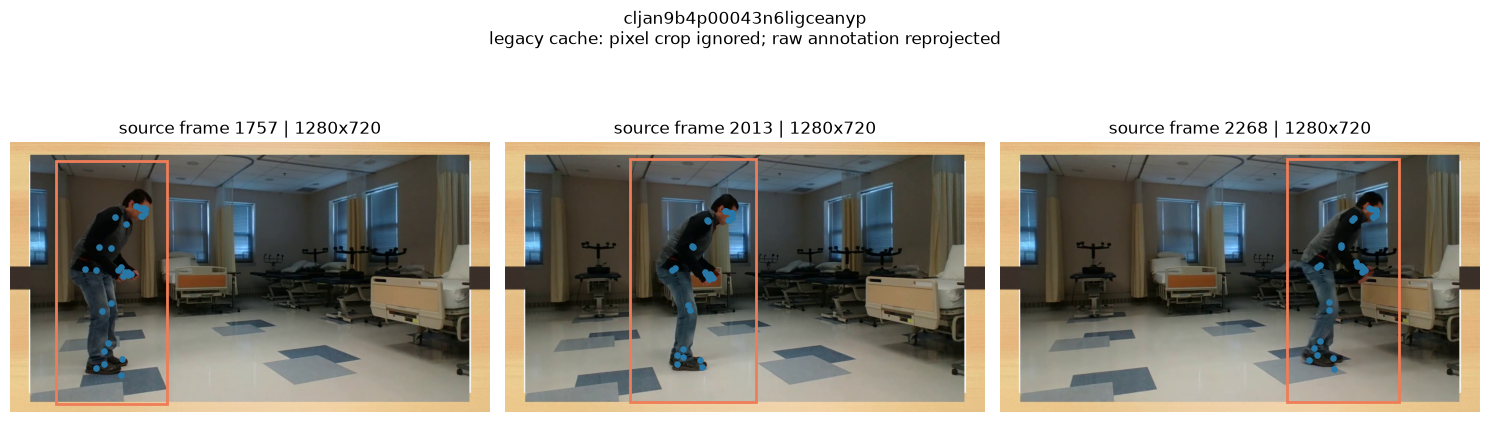

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def preferred_pose_path():
    paths = available_pose_paths()
    return paths[0] if paths else None


def manifest_row_for_sequence(sequence_id):
    rows = manifest.loc[manifest["sequence_id"].eq(sequence_id)]
    if len(rows) != 1:
        raise ValueError(
            f"Expected one locked manifest row for {sequence_id}, got {len(rows)}"
        )
    return rows.iloc[0]


def show_alignment_triptych(path):
    with np.load(path, allow_pickle=False) as data:
        sequence = np.array(data["sequence"], copy=True)
        frame_numbers = data["frame_numbers"].astype(int).copy()
        sequence_id = str(data["sequence_id"].item())
        condition = str(data["condition"].item())
        video_id = str(data["video_id"].item())
        video_path = Path(str(data["source_video"].item()))
        legacy_pixel_geometry = not {
            "frame_sizes", "crop_bounds_normalized"
        }.issubset(data.files)

    locked_row = manifest_row_for_sequence(sequence_id)
    annotations = pd.read_csv(locked_row["csv_path"])
    annotations["frame_num"] = annotations["frame_num"].astype(int)
    if annotations["frame_num"].duplicated().any():
        raise ValueError(f"Duplicate annotated frame in {locked_row['csv_path']}")
    annotations = annotations.set_index("frame_num", drop=False)
    if video_path.is_file():
        resolved_from = "cache provenance path"
    else:
        # The absolute path may name the lower-resolution machine that created
        # a legacy cache. Resolve the immutable source ID in this run instead.
        video_path = find_video(condition, video_id)
        resolved_from = "current video cache (provenance path unavailable)"

    sample_indices = [0, len(sequence) // 2, len(sequence) - 1]
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        capture.release()
        raise RuntimeError(f"Could not open preview video {video_path}")
    figure, axes = plt.subplots(1, 3, figsize=(15, 5))
    displayed_resolutions, displayed_bounds = [], []
    try:
        for axis, sample_index in zip(axes, sample_indices):
            frame_number = int(frame_numbers[sample_index])
            capture.set(cv2.CAP_PROP_POS_FRAMES, frame_number - 1)
            ok, frame = capture.read()
            if not ok:
                raise RuntimeError(f"Could not decode frame {frame_number}")
            if frame_number not in annotations.index:
                raise ValueError(
                    f"Frame {frame_number} is absent from {locked_row['csv_path']}"
                )
            annotation = annotations.loc[frame_number]
            x0, y0, x1, y1 = scaled_crop_bounds(
                annotation, frame.shape, padding=0.15
            )
            height, width = frame.shape[:2]
            displayed_resolutions.append((width, height))
            displayed_bounds.append((x0, y0, x1, y1))
            axis.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            axis.add_patch(Rectangle(
                (x0, y0), x1 - x0, y1 - y0,
                fill=False, edgecolor="#ef7d57", linewidth=2,
                label="annotation crop (+15%)",
            ))
            pose = sequence[sample_index]
            visible = (
                np.isfinite(pose[:, :2]).all(axis=1)
                & (pose[:, 3] > 0.0)
            )
            axis.scatter(
                pose[visible, 0] * width,
                pose[visible, 1] * height,
                s=14,
                c="#2878a7",
                label="cached normalized landmarks",
            )
            axis.set_title(
                f"source frame {frame_number} | {width}x{height}"
            )
            axis.axis("off")
    finally:
        capture.release()

    geometry_note = (
        "legacy cache: pixel crop ignored; raw annotation reprojected"
        if legacy_pixel_geometry
        else "resolution-explicit cache; raw annotation independently reprojected"
    )
    figure.suptitle(f"{sequence_id}\n{geometry_note}")
    figure.tight_layout()
    preview_path = ARTIFACT_DIR / "pose_alignment_triptych.png"
    figure.savefig(preview_path, dpi=160, bbox_inches="tight")
    print({
        "video": str(video_path),
        "resolved_from": resolved_from,
        "displayed_resolutions": displayed_resolutions,
        "reprojected_annotation_bounds": displayed_bounds,
        "saved_preview": str(preview_path),
    })
    plt.show()


if MODE == "real":
    pose_path = preferred_pose_path()
    if pose_path is None:
        print(real_pose_instructions())
    else:
        show_alignment_triptych(pose_path)
else:
    print("Smoke mode has no source frames. Run this gate in real mode.")


## Watch the skeleton

The animation below is generated directly in the notebook and does not need
FFmpeg. In real mode it loads the first locked-manifest sequence; filesystem
extras are never preview candidates. In smoke mode it uses a clearly named
synthetic walk. Animation subsampling changes display size only—extraction and
QC retain the complete annotated timeline.


In [10]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

POSE_CONNECTIONS = [
    (11, 12), (11, 23), (12, 24), (23, 24),
    (11, 13), (13, 15), (12, 14), (14, 16),
    (23, 25), (25, 27), (27, 29), (29, 31),
    (24, 26), (26, 28), (28, 30), (30, 32),
]


def first_sequence_for_preview():
    if MODE == "smoke":
        return (
            synthetic_gait_sequence("normal", frames=64, seed=7),
            "smoke_normal",
            30.0,
        )
    paths = available_pose_paths()
    if not paths:
        return None
    data = np.load(paths[0], allow_pickle=False)
    return (
        data["sequence"],
        str(data["sequence_id"].item()),
        float(data["fps"].item()),
    )


def skeleton_animation(sequence, title, fps, max_rendered_frames=64):
    sequence = np.asarray(sequence)
    fig, ax = plt.subplots(figsize=(5.2, 5.2))
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("normalized x")
    ax.set_ylabel("normalized y")
    points = ax.scatter([], [], s=26, c="#ef7d57")
    lines = [
        ax.plot([], [], color="#17324d", linewidth=2)[0]
        for _ in POSE_CONNECTIONS
    ]

    def update(frame_index):
        frame = sequence[frame_index]
        visible = np.isfinite(frame[:, :2]).all(axis=1) & (frame[:, 3] > 0.0)
        points.set_offsets(frame[visible, :2])
        for line, (start, end) in zip(lines, POSE_CONNECTIONS):
            if visible[start] and visible[end]:
                line.set_data(
                    [frame[start, 0], frame[end, 0]],
                    [frame[start, 1], frame[end, 1]],
                )
            else:
                line.set_data([], [])
        return [points, *lines]

    # Bound embedded HTML size while sampling the complete timeline.
    # Extraction/QC always use every frame; this stride affects preview only.
    stride = max(1, int(np.ceil(len(sequence) / max_rendered_frames)))
    animation = FuncAnimation(
        fig,
        update,
        frames=range(0, len(sequence), stride),
        interval=1000.0 * stride / fps,
        blit=True,
    )
    plt.close(fig)
    return HTML(animation.to_jshtml())


preview = first_sequence_for_preview()
if preview is None:
    preview_sequence = preview_name = preview_fps = None
    print(real_pose_instructions())
else:
    preview_sequence, preview_name, preview_fps = preview
    if MODE == "smoke":
        frame = preview_sequence[0]
        visible = np.isfinite(frame[:, :2]).all(axis=1) & (frame[:, 3] > 0.0)
        fig, ax = plt.subplots(figsize=(5.2, 5.2))
        ax.scatter(frame[visible, 0], frame[visible, 1], s=26, c="#ef7d57")
        for start, end in POSE_CONNECTIONS:
            if visible[start] and visible[end]:
                ax.plot(frame[[start, end], 0], frame[[start, end], 1], color="#17324d", linewidth=2)
        ax.set(xlim=(0, 1), ylim=(1, 0), aspect="equal", title=f"{preview_name}: smoke-mode frame 0")
        ax.set_xlabel("normalized x")
        ax.set_ylabel("normalized y")
        plt.show()
        print("Smoke mode uses a static frame; real mode renders the full HTML animation.")
    else:
        display(skeleton_animation(
            preview_sequence, preview_name, preview_fps
        ))


## Inspect confidence without shortening time

A failed pose row stays in the tensor with zero visibility and missing coordinates. Notebook 04 interpolates short coordinate gaps while retaining a validity mask. Removing failed rows would falsely speed up the walk.


In [11]:
if preview_sequence is None:
    print("Confidence audit skipped because no real pose NPZ is available.")
else:
    visibility = np.nan_to_num(preview_sequence[..., 3], nan=0.0)
    coverage = pd.DataFrame({
        "keypoint": BLAZEPOSE_33,
        "mean_visibility": visibility.mean(axis=0),
        "detected_fraction": (visibility > 0.0).mean(axis=0),
    })
    display(coverage.loc[MASK_KEYPOINTS])
    print("frames:", len(preview_sequence))
    print(
        "frames with any detected landmark:",
        float((visibility > 0.0).any(axis=1).mean()),
    )


,keypoint,mean_visibility,detected_fraction
11,LEFT_SHOULDER,0.999280,1.0
12,RIGHT_SHOULDER,0.999914,1.0
23,LEFT_HIP,0.997709,1.0
24,RIGHT_HIP,0.999329,1.0
25,LEFT_KNEE,0.373888,1.0
26,RIGHT_KNEE,0.951178,1.0
27,LEFT_ANKLE,0.491072,1.0
28,RIGHT_ANKLE,0.956900,1.0
29,LEFT_HEEL,0.576695,1.0
30,RIGHT_HEEL,0.935910,1.0


frames: 512
frames with any detected landmark: 1.0


## Quality and leakage gate

Before training, confirm:

- the bbox follows the intended walker and the absolute CSV frame span;
- left/right anatomy and failed rows remain on the original timeline;
- FPS, model hash, source paths, manifest hash, split hash, fold, and role are stored in every NPZ;
- decoded-frame and pose-QC counts are reported separately;
- every `video_id` occupies exactly one role per outer fold;
- pilot filters did not redefine the frozen cohort;
- train code will load train roles only, validation will select settings only, and test will remain unopened until checkpoint freeze.

Passing pose QC makes a row technically usable; it does not establish clinical validity or independence beyond the source-video grouping available in GAVD.


## Visual pose-quality audit

Panel A reveals whether QC attrition changes the class composition of train, validation, or test. Panel B shows the full observed-joint distribution and the predeclared threshold; it is more informative than a single pass count.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


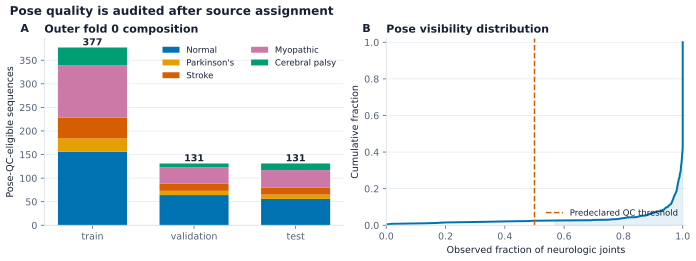

Notebook SVG: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\artifacts\real\figures\bbfm_pose_qc.svg
Paper assets: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_pose_qc.svg C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_pose_qc.png C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_pose_qc.pdf


In [1]:
# Paper and notebook rendering share this single source of truth.
from pathlib import Path as _VisualPath
import os as _visual_os
import sys as _visual_sys


def _find_visual_experiment(start=None):
    start = _VisualPath(start or _VisualPath.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "neurips-brain-body").is_dir() and (candidate / "data-gavd").is_dir():
            return candidate
        nested = candidate / "experiments" / "sjepa" / "gavd5-drift"
        if (nested / "neurips-brain-body").is_dir() and (nested / "data-gavd").is_dir():
            return nested
    raise FileNotFoundError("Could not locate experiments/sjepa/gavd5-drift")


_visual_experiment = _VisualPath(globals().get("EXPERIMENT_DIR", _find_visual_experiment())).resolve()
_visual_notebook_dir = _visual_experiment / "neurips-brain-body"
if str(_visual_notebook_dir) not in _visual_sys.path:
    _visual_sys.path.insert(0, str(_visual_notebook_dir))
try:
    from dotenv import load_dotenv as _visual_load_dotenv
    _visual_load_dotenv(_visual_experiment / ".env", override=False)
except ImportError:
    pass
_visual_mode = str(globals().get("MODE", _visual_os.getenv("GAVD_MODE", "real"))).strip().lower()
_visual_artifact_root = _VisualPath(
    _visual_os.getenv("GAVD_ARTIFACT_DIR", _visual_experiment / "work" / "artifacts")
).expanduser()
_visual_artifact_dir = _VisualPath(globals().get("ARTIFACT_DIR", _visual_artifact_root / _visual_mode))
_visual_outer_fold = int(globals().get("OUTER_FOLD", _visual_os.getenv("SJEPA_OUTER_FOLD", "0")))
_visual_seed = int(globals().get("MODEL_SEED", _visual_os.getenv("SJEPA_MODEL_SEED", "42")))
_visual_objective = str(globals().get("OBJECTIVE_NAME", _visual_os.getenv("SJEPA_OBJECTIVE", "jepa_vicreg")))

from scientific_visuals import render_notebook_summary

visual_summary = render_notebook_summary(
    "02",
    experiment_dir=_visual_experiment,
    artifact_dir=_visual_artifact_dir,
    outer_fold=_visual_outer_fold,
    model_seed=_visual_seed,
    objective=_visual_objective,
)
print("Notebook SVG:", visual_summary.notebook_svg)
print("Paper assets:", visual_summary.paper_svg, visual_summary.paper_png, visual_summary.paper_pdf)
